In [ ]:
# --- bootstrap: anchor to the repository root, wherever this notebook was opened from ---
# Notebooks live two levels deep under notebooks/, so the cwd-relative path logic below needs the
# root established first. Keyed on pytest.ini, which is not tied to any folder-naming decision.
import os
import sys
from pathlib import Path

_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pytest.ini").exists())
os.chdir(_root)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
print(f"repo root: {_root}")

# Basic EDA: WRDS RavenPack Connection and Data Sanity Checks

This notebook is an initial data-access and pipeline validation step for the final project. The goal is not to make a final predictive claim yet. Instead, this notebook checks whether we can successfully connect to WRDS, access RavenPack news tables, query relevant sentiment fields, align news timestamps to trading dates, and join RavenPack news aggregates with WRDS market data.

For this first pass, we use RavenPack global macro news and major US market indexes as a simple test case. This lets us verify the workflow before moving to the final project dataset: firm-level RavenPack news matched to S&P 500 constituent returns.

No raw RavenPack articles, headlines, or restricted WRDS files are saved by this notebook. The notebook only works with derived aggregates and sanity-check outputs.

In [ ]:
%pip install -q wrds psycopg2-binary pandas numpy matplotlib seaborn pyarrow


In [1]:
import warnings
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wrds

warnings.filterwarnings("ignore", category=FutureWarning)

pd.options.display.max_columns = 120
pd.options.display.max_rows = 80
sns.set_theme(style="whitegrid", context="notebook")


In [2]:
# This first EDA uses macro RavenPack news and index-level data only as a WRDS connection
# and data-pipeline sanity check. The final project will move to firm-level S&P 500 news.

START_DATE = "2020-01-01"
END_DATE = "2025-12-31"
YEARS = range(2020, 2026)

RELEVANCE_MIN = 90
EVENT_RELEVANCE_MIN = 90
MARKET_CLOSE_ET = "16:00:00"

# WRDS Compustat index identifiers discovered from comp.idx_index.
INDEX_TARGETS = {
    "SPX": {
        "gvkeyx": "000003",
        "display_name": "S&P 500 Composite",
        "compustat_name": "S&P 500 Comp-Ltd",
    },
    "NASDAQ_COMPOSITE": {
        "gvkeyx": "000008",
        "display_name": "Nasdaq Composite",
        "compustat_name": "Nasdaq Index Composite",
    },
    "DOW_JONES_INDUSTRIALS": {
        "gvkeyx": "000005",
        "display_name": "Dow Jones Industrial Average",
        "compustat_name": "Dow Jones Industrials-30 Stk",
    },
    "SOX": {
        "gvkeyx": "000180",
        "display_name": "PHLX Semiconductor Index",
        "compustat_name": "PHLX SEMICONDUCTOR INDEX",
    },
}

TARGET_GVKEYX = tuple(target["gvkeyx"] for target in INDEX_TARGETS.values())
GVKEYX_TO_ASSET = {target["gvkeyx"]: asset for asset, target in INDEX_TARGETS.items()}
ASSET_DISPLAY_NAMES = {asset: target["display_name"] for asset, target in INDEX_TARGETS.items()}

print(f"Date range: {START_DATE} to {END_DATE}")
print("Index universe:")
for asset, target in INDEX_TARGETS.items():
    print(f"  {asset}: {target['display_name']} (gvkeyx={target['gvkeyx']})")


Date range: 2020-01-01 to 2025-12-31
Index universe:
  SPX: S&P 500 Composite (gvkeyx=000003)
  NASDAQ_COMPOSITE: Nasdaq Composite (gvkeyx=000008)
  DOW_JONES_INDUSTRIALS: Dow Jones Industrial Average (gvkeyx=000005)
  SOX: PHLX Semiconductor Index (gvkeyx=000180)


In [3]:
# Connect to WRDS. This may prompt for credentials if no .pgpass file is configured.
db = wrds.Connection()

rp_tables = db.list_tables(library="rpna")
expected_rp_tables = [f"rpa_djpr_global_macro_{year}" for year in YEARS]
missing_rp_tables = [table for table in expected_rp_tables if table not in rp_tables]

if missing_rp_tables:
    raise RuntimeError(f"Missing RavenPack tables: {missing_rp_tables}")

print("WRDS connection ready.")
print("RavenPack macro tables found:", expected_rp_tables)


WRDS recommends setting up a .pgpass file.
pgpass file created at C:\Users\dongx\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
WRDS connection ready.
RavenPack macro tables found: ['rpa_djpr_global_macro_2020', 'rpa_djpr_global_macro_2021', 'rpa_djpr_global_macro_2022', 'rpa_djpr_global_macro_2023', 'rpa_djpr_global_macro_2024', 'rpa_djpr_global_macro_2025']


## 1. Verify RavenPack source metadata and source filters

This section checks whether RavenPack source metadata can be queried correctly from WRDS. We filter to high-quality institutional sources so the basic EDA uses more reliable news records. This is mainly a data-quality check, not a final modeling decision.

In [4]:
source_query = """
    SELECT rp_entity_id, data_type, data_value
    FROM rpna.rpa_source_list
    WHERE data_type IN ('ENTITY_NAME', 'PUBLICATION_TYPE', 'SOURCE_RANK')
"""

raw_source_attributes = db.raw_sql(source_query)

sources_wide = raw_source_attributes.pivot(
    index="rp_entity_id", columns="data_type", values="data_value"
).reset_index()
sources_wide.columns.name = None

sources_df = sources_wide.rename(columns={
    "ENTITY_NAME": "source_name",
    "PUBLICATION_TYPE": "source_type",
    "SOURCE_RANK": "source_rank",
})

sources_df["source_rank"] = pd.to_numeric(sources_df["source_rank"], errors="coerce")
sources_df["is_rank1_non_blog"] = (
    sources_df["source_rank"].eq(1)
    & sources_df["source_type"].notna()
    & sources_df["source_type"].ne("BLOG")
)

institutional_sources_df = sources_df.loc[sources_df["is_rank1_non_blog"]].copy()
institutional_sources_df["weight"] = 1.0
valid_source_ids = institutional_sources_df["rp_entity_id"].dropna().astype(str).tolist()

print(f"All RavenPack source entities: {len(sources_df):,}")
print(f"Rank-1 non-blog institutional sources: {len(institutional_sources_df):,}")
display(institutional_sources_df.head())


All RavenPack source entities: 25,988
Rank-1 non-blog institutional sources: 372


,rp_entity_id,source_name,source_type,source_rank,is_rank1_non_blog,weight
98,00F402,Independent News Ireland,NEWS,1,True,1.0
100,01032F,United Kingdom Parliament,NEWS,1,True,1.0
110,011E22,The Auto Channel,NEWS,1,True,1.0
170,01BDCE,The Mercury News,NEWS,1,True,1.0
199,01EFD4,Pressetext News,NEWS,1,True,1.0


## 2. Check RavenPack sentiment score availability

This section verifies that RavenPack sentiment scores are available, numeric, and usable for later analysis. At this stage, the goal is only to understand the score distribution, not to claim that sentiment predicts returns.


In [5]:
def sql_string_list(values):
    """Return a SQL-safe single-quoted literal list for simple identifier strings."""
    return ", ".join("'" + str(value).replace("'", "''") + "'" for value in values)

source_id_sql = sql_string_list(valid_source_ids)

score_sample_query = f"""
    SELECT event_sentiment_score
    FROM rpna.rpa_djpr_global_macro_{max(YEARS)}
    WHERE rpa_date_utc BETWEEN '{START_DATE}' AND '{END_DATE}'
      AND relevance >= {RELEVANCE_MIN}
      AND event_relevance >= {EVENT_RELEVANCE_MIN}
      AND rp_source_id IN ({source_id_sql})
      AND event_sentiment_score IS NOT NULL
    LIMIT 10000
"""

score_sample_df = db.raw_sql(score_sample_query)
score_sample_df["event_sentiment_score"] = pd.to_numeric(
    score_sample_df["event_sentiment_score"], errors="coerce"
)
score_sample = score_sample_df["event_sentiment_score"].dropna()

if score_sample.empty:
    raise RuntimeError("No RavenPack event_sentiment_score values found for the configured filters.")

score_min = float(score_sample.min())
score_max = float(score_sample.max())
score_mean = float(score_sample.mean())

if score_min >= -1.5 and score_max <= 1.5:
    SENTIMENT_NEGATIVE_MAX = -0.05
    SENTIMENT_POSITIVE_MIN = 0.05
    SENTIMENT_SCALE_NOTE = "approx. -1 to 1 scale"
elif score_min >= 0 and score_max <= 100:
    SENTIMENT_NEGATIVE_MAX = 50.0
    SENTIMENT_POSITIVE_MIN = 50.0
    SENTIMENT_SCALE_NOTE = "approx. 0 to 100 scale"
else:
    SENTIMENT_NEGATIVE_MAX = -1.0
    SENTIMENT_POSITIVE_MIN = 1.0
    SENTIMENT_SCALE_NOTE = "wide signed scale fallback"

print({
    "sample_rows": len(score_sample),
    "min": score_min,
    "mean": score_mean,
    "max": score_max,
    "scale_note": SENTIMENT_SCALE_NOTE,
    "negative_if_less_than": SENTIMENT_NEGATIVE_MAX,
    "positive_if_greater_than": SENTIMENT_POSITIVE_MIN,
})


{'sample_rows': 10000, 'min': -0.96, 'mean': 0.10578299999999999, 'max': 0.95, 'scale_note': 'approx. -1 to 1 scale', 'negative_if_less_than': -0.05, 'positive_if_greater_than': 0.05}


## 3. Pull WRDS market index data for a simple market-side check

This section pulls index-level market data from WRDS/Compustat. These indexes are used only for this basic EDA because they provide a simple way to test whether RavenPack news aggregates can be aligned with market returns. The final project will move from index-level data to firm-level S&P 500 constituent returns.

In [6]:
def fetch_market_index_data(db):
    gvkeyx_sql = sql_string_list(TARGET_GVKEYX)
    query = f"""
        SELECT
            d.datadate AS session_date,
            i.gvkeyx,
            i.conm AS index_name,
            i.tic AS index_symbol,
            i.indexcat,
            i.indexgeo,
            i.indexid,
            i.indextype,
            d.prccd AS close_level,
            d.prchd AS high_level,
            d.prcld AS low_level,
            d.dvpsxd,
            d.prccddiv,
            d.prccddivn
        FROM comp.idx_daily d
        INNER JOIN comp.idx_index i
            ON d.gvkeyx = i.gvkeyx
        WHERE d.gvkeyx IN ({gvkeyx_sql})
          AND d.datadate BETWEEN DATE '{START_DATE}' AND DATE '{END_DATE}'
        ORDER BY i.gvkeyx, d.datadate
    """
    return db.raw_sql(query)

market_daily_raw = fetch_market_index_data(db)
if market_daily_raw.empty:
    raise RuntimeError("No Compustat index data returned for configured target indexes.")

market_daily_df = market_daily_raw.copy()
market_daily_df["session_date"] = pd.to_datetime(market_daily_df["session_date"])
market_daily_df["gvkeyx"] = market_daily_df["gvkeyx"].astype(str).str.zfill(6)
market_daily_df["asset"] = market_daily_df["gvkeyx"].map(GVKEYX_TO_ASSET)
market_daily_df["display_name"] = market_daily_df["asset"].map(ASSET_DISPLAY_NAMES)

for col in ["close_level", "high_level", "low_level", "dvpsxd", "prccddiv", "prccddivn"]:
    market_daily_df[col] = pd.to_numeric(market_daily_df[col], errors="coerce")

market_daily_df = (
    market_daily_df
    .dropna(subset=["asset", "session_date", "close_level"])
    .sort_values(["asset", "session_date"])
    .drop_duplicates(["asset", "session_date"], keep="last")
    .reset_index(drop=True)
)

market_daily_df["daily_return"] = market_daily_df.groupby("asset")["close_level"].pct_change()

for horizon in [1, 5]:
    shifted_product = pd.Series(1.0, index=market_daily_df.index)
    for lag in range(1, horizon + 1):
        shifted_product = shifted_product * (1 + market_daily_df.groupby("asset")["daily_return"].shift(-lag))
    fwd_col = f"fwd_{horizon}d_return"
    label_col = f"fwd_{horizon}d_positive"
    market_daily_df[fwd_col] = shifted_product - 1
    market_daily_df[label_col] = np.where(
        market_daily_df[fwd_col].notna(),
        (market_daily_df[fwd_col] > 0).astype(float),
        np.nan,
    )

missing_assets = set(INDEX_TARGETS) - set(market_daily_df["asset"].dropna().unique())
if missing_assets:
    raise RuntimeError(f"Missing target index series: {missing_assets}")

print("WRDS market source used: comp.idx_daily joined to comp.idx_index")
print(market_daily_df.groupby(["asset", "display_name", "index_symbol", "gvkeyx"]).agg(
    start=("session_date", "min"),
    end=("session_date", "max"),
    sessions=("session_date", "nunique"),
    nonnull_returns=("daily_return", "count"),
    min_close=("close_level", "min"),
    max_close=("close_level", "max"),
))
display(market_daily_df.head())


WRDS market source used: comp.idx_daily joined to comp.idx_index
                                                                            start  \
asset                 display_name                 index_symbol gvkeyx              
DOW_JONES_INDUSTRIALS Dow Jones Industrial Average I0005        000005 2020-01-02   
NASDAQ_COMPOSITE      Nasdaq Composite             I0008        000008 2020-01-02   
SOX                   PHLX Semiconductor Index     I0319        000180 2020-01-02   
SPX                   S&P 500 Composite            I0003        000003 2020-01-02   

                                                                              end  \
asset                 display_name                 index_symbol gvkeyx              
DOW_JONES_INDUSTRIALS Dow Jones Industrial Average I0005        000005 2025-12-31   
NASDAQ_COMPOSITE      Nasdaq Composite             I0008        000008 2025-12-31   
SOX                   PHLX Semiconductor Index     I0319        000180 2025-12-31   

,session_date,gvkeyx,index_name,index_symbol,indexcat,indexgeo,indexid,indextype,close_level,high_level,low_level,dvpsxd,prccddiv,prccddivn,asset,display_name,daily_return,fwd_1d_return,fwd_1d_positive,fwd_5d_return,fwd_5d_positive
0,2020-01-02,000005,Dow Jones Industrials-30 Stk,I0005,DOW,USA,NONE,NONE,28868.8,28872.8,28627.77,<NA>,<NA>,<NA>,DOW_JONES_INDUSTRIALS,Dow Jones Industrial Average,<NA>,-0.008103,0.0,0.003052,1.0
1,2020-01-03,000005,Dow Jones Industrials-30 Stk,I0005,DOW,USA,NONE,NONE,28634.88,28716.31,28500.36,<NA>,<NA>,<NA>,DOW_JONES_INDUSTRIALS,Dow Jones Industrial Average,-0.008103,0.002392,1.0,0.006597,1.0
2,2020-01-06,000005,Dow Jones Industrials-30 Stk,I0005,DOW,USA,NONE,NONE,28703.38,28708.02,28418.63,<NA>,<NA>,<NA>,DOW_JONES_INDUSTRIALS,Dow Jones Industrial Average,0.002392,-0.00417,0.0,0.007096,1.0
3,2020-01-07,000005,Dow Jones Industrials-30 Stk,I0005,DOW,USA,NONE,NONE,28583.68,28685.5,28565.28,<NA>,<NA>,<NA>,DOW_JONES_INDUSTRIALS,Dow Jones Industrial Average,-0.00417,0.005647,1.0,0.012454,1.0
4,2020-01-08,000005,Dow Jones Industrials-30 Stk,I0005,DOW,USA,NONE,NONE,28745.09,28866.18,28522.51,<NA>,<NA>,<NA>,DOW_JONES_INDUSTRIALS,Dow Jones Industrial Average,0.005647,0.007369,1.0,0.009919,1.0


In [8]:
print("Market data shape:", market_daily_df.shape)
print("Date range:", market_daily_df["session_date"].min(), "to", market_daily_df["session_date"].max())
print("Assets:", market_daily_df["asset"].unique())

display(market_daily_df.isna().mean().sort_values(ascending=False).head(10))
display(market_daily_df.groupby("asset")["session_date"].agg(["min", "max", "count"]))

Market data shape: (6031, 21)
Date range: 2020-01-02 00:00:00 to 2025-12-31 00:00:00
Assets: ['DOW_JONES_INDUSTRIALS' 'NASDAQ_COMPOSITE' 'SOX' 'SPX']


prccddivn          1.000000
dvpsxd             0.749959
prccddiv           0.749959
fwd_5d_positive    0.003316
fwd_5d_return      0.003316
fwd_1d_return      0.000663
daily_return       0.000663
fwd_1d_positive    0.000663
indexcat           0.000000
session_date       0.000000
dtype: float64

,min,max,count
asset,,,
DOW_JONES_INDUSTRIALS,2020-01-02,2025-12-31,1507
NASDAQ_COMPOSITE,2020-01-02,2025-12-31,1508
SOX,2020-01-02,2025-12-31,1508
SPX,2020-01-02,2025-12-31,1508


## 4. Aggregate RavenPack macro news by market signal date

This section tests one of the most important parts of the data pipeline: timestamp alignment. RavenPack timestamps are converted from UTC to Eastern Time, and news released after the 4:00 PM market close is assigned to the next trading session. This helps reduce look-ahead bias in later predictive modeling.

In [7]:
ET_TIMESTAMP_SQL = "((timestamp_utc AT TIME ZONE 'UTC') AT TIME ZONE 'America/New_York')"


def fetch_news_daily_for_year(year):
    table_name = f"rpna.rpa_djpr_global_macro_{year}"
    query = f"""
        SELECT
            CASE
                WHEN {ET_TIMESTAMP_SQL}::time < TIME '{MARKET_CLOSE_ET}'
                    THEN {ET_TIMESTAMP_SQL}::date
                ELSE ({ET_TIMESTAMP_SQL}::date + INTERVAL '1 day')::date
            END AS signal_calendar_date,
            COUNT(*)::bigint AS event_record_count,
            COUNT(DISTINCT rp_story_id)::bigint AS unique_story_count,
            AVG(event_sentiment_score)::float AS mean_event_sentiment_score,
            SUM(CASE WHEN event_sentiment_score > {SENTIMENT_POSITIVE_MIN} THEN 1 ELSE 0 END)::bigint AS positive_event_count,
            SUM(CASE WHEN event_sentiment_score < {SENTIMENT_NEGATIVE_MAX} THEN 1 ELSE 0 END)::bigint AS negative_event_count,
            SUM(CASE WHEN event_sentiment_score >= {SENTIMENT_NEGATIVE_MAX}
                      AND event_sentiment_score <= {SENTIMENT_POSITIVE_MIN}
                     THEN 1 ELSE 0 END)::bigint AS neutral_event_count,
            COUNT(DISTINCT rp_source_id)::bigint AS unique_source_count
        FROM {table_name}
        WHERE rpa_date_utc BETWEEN DATE '{START_DATE}' AND DATE '{END_DATE}'
          AND relevance >= {RELEVANCE_MIN}
          AND event_relevance >= {EVENT_RELEVANCE_MIN}
          AND rp_source_id IN ({source_id_sql})
          AND timestamp_utc IS NOT NULL
          AND event_sentiment_score IS NOT NULL
        GROUP BY 1
        ORDER BY 1
    """
    df = db.raw_sql(query)
    df["source_year"] = year
    return df

news_daily_parts = []
for year in YEARS:
    print(f"Aggregating RavenPack macro news for {year}...")
    news_daily_parts.append(fetch_news_daily_for_year(year))

news_signal_calendar_df = pd.concat(news_daily_parts, ignore_index=True)
news_signal_calendar_df["signal_calendar_date"] = pd.to_datetime(news_signal_calendar_df["signal_calendar_date"])

count_columns = [
    "event_record_count",
    "unique_story_count",
    "positive_event_count",
    "negative_event_count",
    "neutral_event_count",
    "unique_source_count",
]
for col in count_columns:
    news_signal_calendar_df[col] = pd.to_numeric(news_signal_calendar_df[col], errors="coerce").fillna(0)
news_signal_calendar_df["mean_event_sentiment_score"] = pd.to_numeric(
    news_signal_calendar_df["mean_event_sentiment_score"], errors="coerce"
)

print(f"Calendar signal rows: {len(news_signal_calendar_df):,}")
display(news_signal_calendar_df.head())


Aggregating RavenPack macro news for 2020...
Aggregating RavenPack macro news for 2021...
Aggregating RavenPack macro news for 2022...
Aggregating RavenPack macro news for 2023...
Aggregating RavenPack macro news for 2024...
Aggregating RavenPack macro news for 2025...
Calendar signal rows: 2,191


,signal_calendar_date,event_record_count,unique_story_count,mean_event_sentiment_score,positive_event_count,negative_event_count,neutral_event_count,unique_source_count,source_year
0,2020-01-01,8,7,-0.195,3,5,0,2,2020
1,2020-01-02,206,175,-0.006214,69,76,61,5,2020
2,2020-01-03,392,264,-0.021122,141,151,100,4,2020
3,2020-01-04,80,52,-0.09525,27,35,18,4,2020
4,2020-01-05,13,10,-0.353846,2,11,0,2,2020


In [10]:
def map_to_next_trading_session(dates, trading_sessions):
    sessions = pd.Series(pd.to_datetime(trading_sessions)).drop_duplicates().sort_values()
    session_values = sessions.to_numpy(dtype="datetime64[ns]")
    target_values = pd.to_datetime(dates).to_numpy(dtype="datetime64[ns]")
    positions = np.searchsorted(session_values, target_values, side="left")
    mapped = np.full(len(target_values), np.datetime64("NaT"), dtype="datetime64[ns]")
    valid = positions < len(session_values)
    mapped[valid] = session_values[positions[valid]]
    return pd.to_datetime(mapped)

trading_sessions = market_daily_df["session_date"].drop_duplicates().sort_values()

news_aligned = news_signal_calendar_df.copy()
news_aligned["session_date"] = map_to_next_trading_session(
    news_aligned["signal_calendar_date"], trading_sessions
)
news_aligned = news_aligned.dropna(subset=["session_date"])

weighted_score_numerator = (
    news_aligned["mean_event_sentiment_score"] * news_aligned["event_record_count"]
)
news_aligned["sentiment_weighted_sum"] = weighted_score_numerator

news_daily_df = (
    news_aligned
    .groupby("session_date", as_index=False)
    .agg(
        event_record_count=("event_record_count", "sum"),
        unique_story_count=("unique_story_count", "sum"),
        positive_event_count=("positive_event_count", "sum"),
        negative_event_count=("negative_event_count", "sum"),
        neutral_event_count=("neutral_event_count", "sum"),
        unique_source_count=("unique_source_count", "max"),
        sentiment_weighted_sum=("sentiment_weighted_sum", "sum"),
    )
)

news_daily_df["mean_event_sentiment_score"] = (
    news_daily_df["sentiment_weighted_sum"] / news_daily_df["event_record_count"]
)
news_daily_df = news_daily_df.drop(columns=["sentiment_weighted_sum"])

for label in ["positive", "negative", "neutral"]:
    news_daily_df[f"{label}_event_share"] = (
        news_daily_df[f"{label}_event_count"] / news_daily_df["event_record_count"]
    )

conditions = [
    news_daily_df["mean_event_sentiment_score"] > SENTIMENT_POSITIVE_MIN,
    news_daily_df["mean_event_sentiment_score"] < SENTIMENT_NEGATIVE_MAX,
]
news_daily_df["sentiment_bucket"] = np.select(conditions, ["positive", "negative"], default="neutral")

print(f"Trading-session news rows: {len(news_daily_df):,}")
display(news_daily_df.head())


Trading-session news rows: 1,508


,session_date,event_record_count,unique_story_count,positive_event_count,negative_event_count,neutral_event_count,unique_source_count,mean_event_sentiment_score,positive_event_share,negative_event_share,neutral_event_share,sentiment_bucket
0,2020-01-02,214,182,72,81,61,5,-0.013271,0.336449,0.378505,0.285047,neutral
1,2020-01-03,392,264,141,151,100,4,-0.021122,0.359694,0.385204,0.255102,neutral
2,2020-01-06,347,250,139,125,83,7,-0.001787,0.400576,0.360231,0.239193,neutral
3,2020-01-07,389,296,128,136,125,9,-0.002725,0.329049,0.349614,0.321337,neutral
4,2020-01-08,494,328,138,296,60,9,-0.214352,0.279352,0.59919,0.121457,negative


In [11]:
print("RavenPack daily news shape:", news_daily_df.shape)
print("Date range:", news_daily_df["session_date"].min(), "to", news_daily_df["session_date"].max())

display(news_daily_df.isna().mean().sort_values(ascending=False).head(10))
display(news_daily_df[[
    "event_record_count",
    "unique_story_count",
    "mean_event_sentiment_score",
    "positive_event_share",
    "negative_event_share",
    "neutral_event_share"
]].describe())

RavenPack daily news shape: (1508, 12)
Date range: 2020-01-02 00:00:00 to 2025-12-31 00:00:00


session_date                  0.0
event_record_count            0.0
unique_story_count            0.0
positive_event_count          0.0
negative_event_count          0.0
neutral_event_count           0.0
unique_source_count           0.0
mean_event_sentiment_score    0.0
positive_event_share          0.0
negative_event_share          0.0
dtype: float64

,event_record_count,unique_story_count,mean_event_sentiment_score,positive_event_share,negative_event_share,neutral_event_share
count,1508.0,1508.0,1508.0,1508.0,1508.0,1508.0
mean,348.055703,267.594828,0.06106,0.434712,0.307985,0.257303
std,79.852117,54.338121,0.065739,0.066157,0.068775,0.057232
min,108.0,85.0,-0.251244,0.184314,0.117438,0.082734
25%,294.0,231.0,0.021597,0.389879,0.258784,0.218519
50%,341.5,265.0,0.065133,0.434669,0.298692,0.253247
75%,395.0,299.0,0.106292,0.480465,0.349629,0.290867
max,703.0,516.0,0.27917,0.66087,0.657778,0.476562


In [12]:
news_year_summary = (
    news_daily_df.assign(year=news_daily_df["session_date"].dt.year)
    .groupby("year")
    .agg(
        trading_days_with_news=("session_date", "nunique"),
        total_event_records=("event_record_count", "sum"),
        total_unique_stories=("unique_story_count", "sum"),
        avg_daily_events=("event_record_count", "mean"),
        avg_sentiment=("mean_event_sentiment_score", "mean"),
        avg_positive_share=("positive_event_share", "mean"),
        avg_negative_share=("negative_event_share", "mean"),
    )
    .reset_index()
)

display(news_year_summary)

,year,trading_days_with_news,total_event_records,total_unique_stories,avg_daily_events,avg_sentiment,avg_positive_share,avg_negative_share
0,2020,253,79848,64574,315.604743,0.009345,0.39231,0.352801
1,2021,252,84075,66094,333.630952,0.066276,0.436261,0.302448
2,2022,251,93894,71173,374.079681,0.045926,0.430919,0.331633
3,2023,250,90273,68585,361.092,0.063724,0.441444,0.306487
4,2024,252,87444,66022,347.0,0.090059,0.446261,0.271544
5,2025,250,89334,67085,357.336,0.091433,0.461496,0.282698


## 5. Explore RavenPack topic and group coverage

These summary queries help us understand what types of macro news are present in the RavenPack sample. This is a basic coverage check and helps guide future filtering decisions.

In [13]:
def fetch_category_counts_for_year(year, category_col, output_col):
    table_name = f"rpna.rpa_djpr_global_macro_{year}"
    query = f"""
        SELECT
            EXTRACT(YEAR FROM rpa_date_utc)::int AS year,
            COALESCE({category_col}, 'Unknown') AS {output_col},
            COUNT(*)::bigint AS event_record_count,
            COUNT(DISTINCT rp_story_id)::bigint AS unique_story_count
        FROM {table_name}
        WHERE rpa_date_utc BETWEEN DATE '{START_DATE}' AND DATE '{END_DATE}'
          AND relevance >= {RELEVANCE_MIN}
          AND event_relevance >= {EVENT_RELEVANCE_MIN}
          AND rp_source_id IN ({source_id_sql})
          AND event_sentiment_score IS NOT NULL
        GROUP BY 1, 2
        ORDER BY 1, 3 DESC
    """
    return db.raw_sql(query)

topic_counts_df = pd.concat(
    [fetch_category_counts_for_year(year, "topic", "topic") for year in YEARS],
    ignore_index=True,
)
group_counts_df = pd.concat(
    [fetch_category_counts_for_year(year, '"group"', "group_name") for year in YEARS],
    ignore_index=True,
)

for df in [topic_counts_df, group_counts_df]:
    df["event_record_count"] = pd.to_numeric(df["event_record_count"], errors="coerce")
    df["unique_story_count"] = pd.to_numeric(df["unique_story_count"], errors="coerce")

print("Top topics:")
display(topic_counts_df.groupby("topic", as_index=False)["event_record_count"].sum().sort_values("event_record_count", ascending=False).head(15))
print("Top groups:")
display(group_counts_df.groupby("group_name", as_index=False)["event_record_count"].sum().sort_values("event_record_count", ascending=False).head(15))


Top topics:


,topic,event_record_count
0,business,260680
1,economy,222473
4,society,24226
3,politics,15200
2,environment,2327


Top groups:


,group_name,event_record_count
38,products-services,105250
7,commodity-prices,58110
20,foreign-exchange,40606
10,credit,35690
8,consumption,31557
11,credit-ratings,26405
3,balance-of-payments,22833
26,insider-trading,22121
27,interest-rates,20253
28,inventory,18297


## 6. Join news aggregates to market index returns

This section creates a simple analysis panel by joining daily RavenPack macro-news features with WRDS market index returns. Because the macro-news features are market-wide, the same daily news signal is repeated across each index. This is acceptable for this first sanity check, but the final project will require firm-level news matched to firm-level returns.

In [14]:
eda_panel_df = market_daily_df.merge(news_daily_df, on="session_date", how="left")

news_fill_zero_cols = [
    "event_record_count",
    "unique_story_count",
    "positive_event_count",
    "negative_event_count",
    "neutral_event_count",
    "unique_source_count",
    "positive_event_share",
    "negative_event_share",
    "neutral_event_share",
]
for col in news_fill_zero_cols:
    eda_panel_df[col] = eda_panel_df[col].fillna(0)

eda_panel_df["has_macro_news"] = eda_panel_df["event_record_count"] > 0
eda_panel_df["year"] = eda_panel_df["session_date"].dt.year
eda_panel_df["month"] = eda_panel_df["session_date"].dt.to_period("M").dt.to_timestamp()

print(f"Panel shape: {eda_panel_df.shape}")
print("Rows by asset:")
display(eda_panel_df.groupby(["asset", "display_name", "index_symbol"]).size().rename("rows"))
display(eda_panel_df.head())


Panel shape: (6031, 35)
Rows by asset:


asset                  display_name                  index_symbol
DOW_JONES_INDUSTRIALS  Dow Jones Industrial Average  I0005           1507
NASDAQ_COMPOSITE       Nasdaq Composite              I0008           1508
SOX                    PHLX Semiconductor Index      I0319           1508
SPX                    S&P 500 Composite             I0003           1508
Name: rows, dtype: int64

,session_date,gvkeyx,index_name,index_symbol,indexcat,indexgeo,indexid,indextype,close_level,high_level,low_level,dvpsxd,prccddiv,prccddivn,asset,display_name,daily_return,fwd_1d_return,fwd_1d_positive,fwd_5d_return,fwd_5d_positive,event_record_count,unique_story_count,positive_event_count,negative_event_count,neutral_event_count,unique_source_count,mean_event_sentiment_score,positive_event_share,negative_event_share,neutral_event_share,sentiment_bucket,has_macro_news,year,month
0,2020-01-02,000005,Dow Jones Industrials-30 Stk,I0005,DOW,USA,NONE,NONE,28868.8,28872.8,28627.77,<NA>,<NA>,<NA>,DOW_JONES_INDUSTRIALS,Dow Jones Industrial Average,<NA>,-0.008103,0.0,0.003052,1.0,214,182,72,81,61,5,-0.013271,0.336449,0.378505,0.285047,neutral,True,2020,2020-01-01
1,2020-01-03,000005,Dow Jones Industrials-30 Stk,I0005,DOW,USA,NONE,NONE,28634.88,28716.31,28500.36,<NA>,<NA>,<NA>,DOW_JONES_INDUSTRIALS,Dow Jones Industrial Average,-0.008103,0.002392,1.0,0.006597,1.0,392,264,141,151,100,4,-0.021122,0.359694,0.385204,0.255102,neutral,True,2020,2020-01-01
2,2020-01-06,000005,Dow Jones Industrials-30 Stk,I0005,DOW,USA,NONE,NONE,28703.38,28708.02,28418.63,<NA>,<NA>,<NA>,DOW_JONES_INDUSTRIALS,Dow Jones Industrial Average,0.002392,-0.00417,0.0,0.007096,1.0,347,250,139,125,83,7,-0.001787,0.400576,0.360231,0.239193,neutral,True,2020,2020-01-01
3,2020-01-07,000005,Dow Jones Industrials-30 Stk,I0005,DOW,USA,NONE,NONE,28583.68,28685.5,28565.28,<NA>,<NA>,<NA>,DOW_JONES_INDUSTRIALS,Dow Jones Industrial Average,-0.00417,0.005647,1.0,0.012454,1.0,389,296,128,136,125,9,-0.002725,0.329049,0.349614,0.321337,neutral,True,2020,2020-01-01
4,2020-01-08,000005,Dow Jones Industrials-30 Stk,I0005,DOW,USA,NONE,NONE,28745.09,28866.18,28522.51,<NA>,<NA>,<NA>,DOW_JONES_INDUSTRIALS,Dow Jones Industrial Average,0.005647,0.007369,1.0,0.009919,1.0,494,328,138,296,60,9,-0.214352,0.279352,0.59919,0.121457,negative,True,2020,2020-01-01


In [18]:
print("Total RavenPack sources:", len(sources_df))
print("Institutional rank-1 non-blog sources:", len(institutional_sources_df))

display(
    institutional_sources_df[["rp_entity_id", "source_name", "source_type", "source_rank"]]
    .head(20)
)

Total RavenPack sources: 25988
Institutional rank-1 non-blog sources: 372


,rp_entity_id,source_name,source_type,source_rank
98,00F402,Independent News Ireland,NEWS,1
100,01032F,United Kingdom Parliament,NEWS,1
110,011E22,The Auto Channel,NEWS,1
170,01BDCE,The Mercury News,NEWS,1
199,01EFD4,Pressetext News,NEWS,1
247,0269E3,Competition Commission,NEWS,1
291,02D273,Official Web Site of Wimbledon,NEWS,1
317,030697,Nikkei Asian Review,NEWS,1
426,043A2C,U.S. Senate Banking Committee,NEWS,1
434,0449E1,SINA,NEWS,1


## 7. Validation checks

These checks confirm that the joined dataset has the expected structure, no duplicate index-date rows, valid sentiment shares, and correctly constructed forward returns. Passing these checks is the main goal of this basic EDA notebook.

In [15]:
expected_assets = set(INDEX_TARGETS.keys())
actual_assets = set(market_daily_df["asset"].dropna().unique())
assert expected_assets.issubset(actual_assets), f"Missing assets: {expected_assets - actual_assets}"

panel_duplicate_count = eda_panel_df.duplicated(["asset", "session_date"]).sum()
assert panel_duplicate_count == 0, f"Duplicate asset-session rows found: {panel_duplicate_count}"

if not news_daily_df.empty:
    assert (news_daily_df["unique_story_count"] <= news_daily_df["event_record_count"]).all(), (
        "unique_story_count should not exceed event_record_count"
    )
    share_sum = news_daily_df[["positive_event_share", "negative_event_share", "neutral_event_share"]].sum(axis=1)
    assert np.allclose(share_sum, 1.0, atol=1e-6), "Sentiment shares do not sum to 1.0"

# Forward return spot check: today's fwd_1d_return must equal tomorrow's daily_return by index.
check_df = market_daily_df.sort_values(["asset", "session_date"]).copy()
check_df["next_daily_return"] = check_df.groupby("asset")["daily_return"].shift(-1)
valid_check = check_df[["fwd_1d_return", "next_daily_return"]].dropna()
assert np.allclose(valid_check["fwd_1d_return"], valid_check["next_daily_return"], atol=1e-12), (
    "fwd_1d_return is not shifted correctly"
)

coverage_summary = eda_panel_df.groupby("asset").agg(
    sessions=("session_date", "nunique"),
    sessions_with_macro_news=("has_macro_news", "sum"),
    missing_daily_return=("daily_return", lambda s: s.isna().sum()),
    missing_fwd_1d=("fwd_1d_return", lambda s: s.isna().sum()),
    missing_fwd_5d=("fwd_5d_return", lambda s: s.isna().sum()),
)
coverage_summary["macro_news_coverage_share"] = (
    coverage_summary["sessions_with_macro_news"] / coverage_summary["sessions"]
)

display(coverage_summary)
print("Validation checks passed.")


,sessions,sessions_with_macro_news,missing_daily_return,missing_fwd_1d,missing_fwd_5d,macro_news_coverage_share
asset,,,,,,
DOW_JONES_INDUSTRIALS,1507,1507,1.0,1.0,5.0,1.0
NASDAQ_COMPOSITE,1508,1508,1.0,1.0,5.0,1.0
SOX,1508,1508,1.0,1.0,5.0,1.0
SPX,1508,1508,1.0,1.0,5.0,1.0


Validation checks passed.


In [16]:
# Spot-check after-hours alignment without retrieving article text.
after_hours_query = f"""
    SELECT
        timestamp_utc,
        {ET_TIMESTAMP_SQL} AS timestamp_et,
        CASE
            WHEN {ET_TIMESTAMP_SQL}::time < TIME '{MARKET_CLOSE_ET}'
                THEN {ET_TIMESTAMP_SQL}::date
            ELSE ({ET_TIMESTAMP_SQL}::date + INTERVAL '1 day')::date
        END AS signal_calendar_date,
        event_sentiment_score,
        source_name
    FROM rpna.rpa_djpr_global_macro_{max(YEARS)}
    WHERE rpa_date_utc BETWEEN DATE '{START_DATE}' AND DATE '{END_DATE}'
      AND relevance >= {RELEVANCE_MIN}
      AND event_relevance >= {EVENT_RELEVANCE_MIN}
      AND rp_source_id IN ({source_id_sql})
      AND timestamp_utc IS NOT NULL
      AND {ET_TIMESTAMP_SQL}::time >= TIME '{MARKET_CLOSE_ET}'
    LIMIT 10
"""

after_hours_spot_check_df = db.raw_sql(after_hours_query)
after_hours_spot_check_df["signal_calendar_date"] = pd.to_datetime(after_hours_spot_check_df["signal_calendar_date"])
after_hours_spot_check_df["mapped_session_date"] = map_to_next_trading_session(
    after_hours_spot_check_df["signal_calendar_date"], trading_sessions
)
display(after_hours_spot_check_df)


,timestamp_utc,timestamp_et,signal_calendar_date,event_sentiment_score,source_name,mapped_session_date
0,2025-01-01 22:33:07.552,2025-01-01 17:33:07.552,2025-01-02,0.49,Dow Jones Newswires,2025-01-02
1,2025-01-01 22:48:07.489,2025-01-01 17:48:07.489,2025-01-02,0.49,Dow Jones Newswires,2025-01-02
2,2025-01-01 00:01:09.176,2024-12-31 19:01:09.176,2025-01-01,0.44,Dow Jones Newswires,2025-01-02
3,2025-01-01 00:03:28.373,2024-12-31 19:03:28.373,2025-01-01,0.24,Dow Jones Newswires,2025-01-02
4,2025-01-01 00:04:45.353,2024-12-31 19:04:45.353,2025-01-01,0.8,Dow Jones Newswires,2025-01-02
5,2025-01-01 00:06:20.734,2024-12-31 19:06:20.734,2025-01-01,0.44,Dow Jones Newswires,2025-01-02
6,2025-01-01 00:06:20.774,2024-12-31 19:06:20.774,2025-01-01,0.24,Dow Jones Newswires,2025-01-02
7,2025-01-01 00:06:20.782,2024-12-31 19:06:20.782,2025-01-01,0.8,Dow Jones Newswires,2025-01-02
8,2025-01-01 00:06:20.791,2024-12-31 19:06:20.791,2025-01-01,0.6,Dow Jones Newswires,2025-01-02
9,2025-01-01 00:06:20.802,2024-12-31 19:06:20.802,2025-01-01,0.43,Dow Jones Newswires,2025-01-02


In [19]:
after_hours_share_query = f"""
    SELECT
        COUNT(*)::bigint AS total_records,
        SUM(CASE WHEN {ET_TIMESTAMP_SQL}::time >= TIME '{MARKET_CLOSE_ET}' THEN 1 ELSE 0 END)::bigint AS after_close_records
    FROM rpna.rpa_djpr_global_macro_{max(YEARS)}
    WHERE rpa_date_utc BETWEEN DATE '{START_DATE}' AND DATE '{END_DATE}'
      AND relevance >= {RELEVANCE_MIN}
      AND event_relevance >= {EVENT_RELEVANCE_MIN}
      AND rp_source_id IN ({source_id_sql})
      AND timestamp_utc IS NOT NULL
      AND event_sentiment_score IS NOT NULL
"""

after_hours_share_df = db.raw_sql(after_hours_share_query)
after_hours_share_df["after_close_share"] = (
    after_hours_share_df["after_close_records"] / after_hours_share_df["total_records"]
)

display(after_hours_share_df)

,total_records,after_close_records,after_close_share
0,89353,21753,0.24345


## 8. Basic sanity-check plots

The following plots are exploratory checks of coverage, sentiment distribution, topic composition, market return behavior, and simple sentiment-return relationships. These visuals are not formal hypothesis tests. They are meant to confirm that the WRDS/RavenPack pipeline produces reasonable data for future modeling.

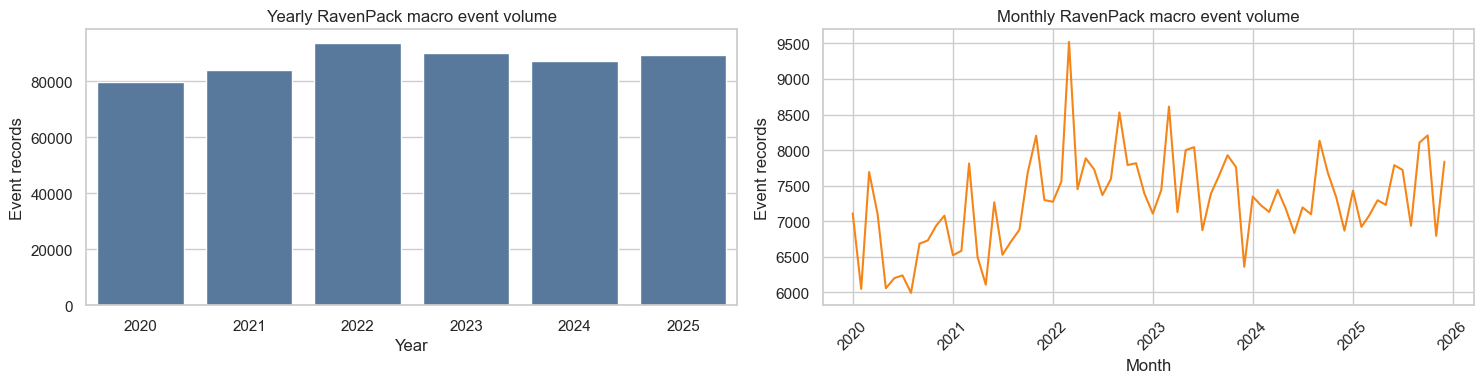

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

news_yearly = news_daily_df.assign(year=news_daily_df["session_date"].dt.year).groupby("year", as_index=False)["event_record_count"].sum()
sns.barplot(data=news_yearly, x="year", y="event_record_count", ax=axes[0], color="#4C78A8")
axes[0].set_title("Yearly RavenPack macro event volume")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Event records")

news_monthly = news_daily_df.assign(month=news_daily_df["session_date"].dt.to_period("M").dt.to_timestamp()).groupby("month", as_index=False)["event_record_count"].sum()
sns.lineplot(data=news_monthly, x="month", y="event_record_count", ax=axes[1], color="#F58518")
axes[1].set_title("Monthly RavenPack macro event volume")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Event records")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


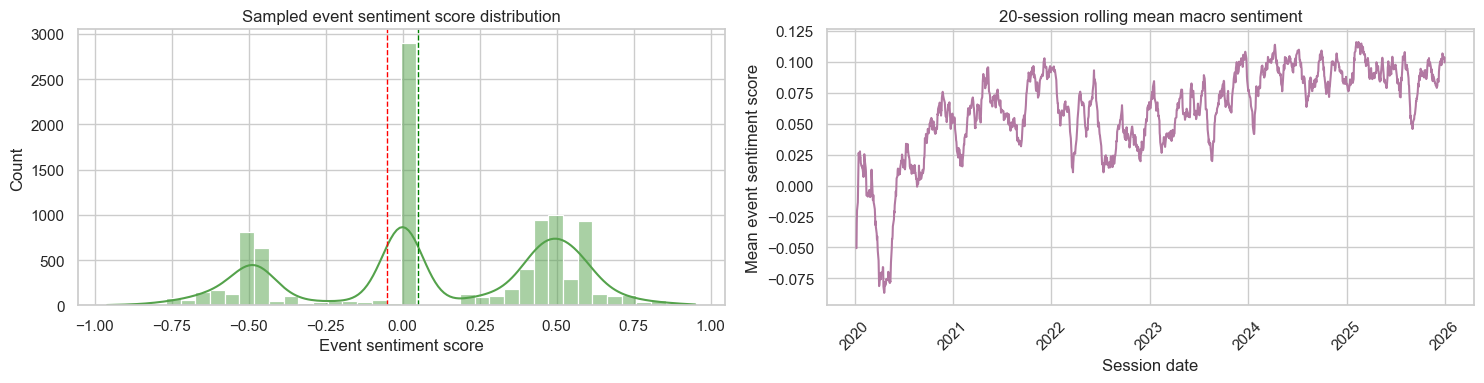

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

sns.histplot(score_sample, bins=40, kde=True, ax=axes[0], color="#54A24B")
axes[0].axvline(SENTIMENT_NEGATIVE_MAX, color="red", linestyle="--", linewidth=1)
axes[0].axvline(SENTIMENT_POSITIVE_MIN, color="green", linestyle="--", linewidth=1)
axes[0].set_title("Sampled event sentiment score distribution")
axes[0].set_xlabel("Event sentiment score")

trend_df = news_daily_df.sort_values("session_date").copy()
trend_df["sentiment_20d_avg"] = trend_df["mean_event_sentiment_score"].rolling(20, min_periods=5).mean()
sns.lineplot(data=trend_df, x="session_date", y="sentiment_20d_avg", ax=axes[1], color="#B279A2")
axes[1].set_title("20-session rolling mean macro sentiment")
axes[1].set_xlabel("Session date")
axes[1].set_ylabel("Mean event sentiment score")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


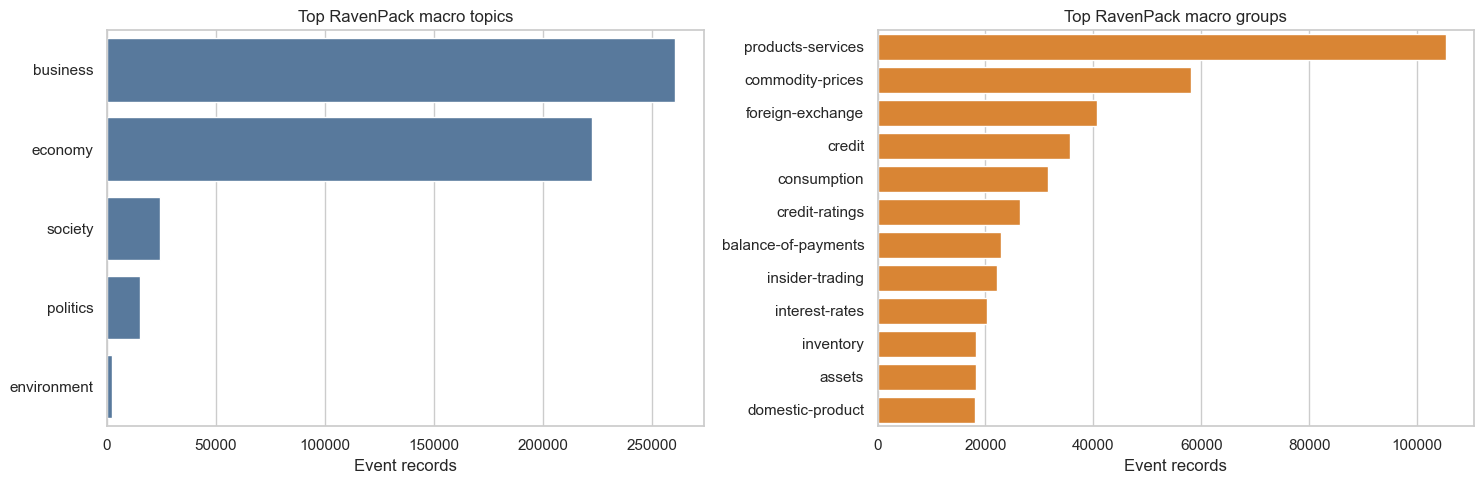

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top_topics = (
    topic_counts_df.groupby("topic", as_index=False)["event_record_count"].sum()
    .sort_values("event_record_count", ascending=False)
    .head(12)
)
sns.barplot(data=top_topics, y="topic", x="event_record_count", ax=axes[0], color="#4C78A8")
axes[0].set_title("Top RavenPack macro topics")
axes[0].set_xlabel("Event records")
axes[0].set_ylabel("")

top_groups = (
    group_counts_df.groupby("group_name", as_index=False)["event_record_count"].sum()
    .sort_values("event_record_count", ascending=False)
    .head(12)
)
sns.barplot(data=top_groups, y="group_name", x="event_record_count", ax=axes[1], color="#F58518")
axes[1].set_title("Top RavenPack macro groups")
axes[1].set_xlabel("Event records")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


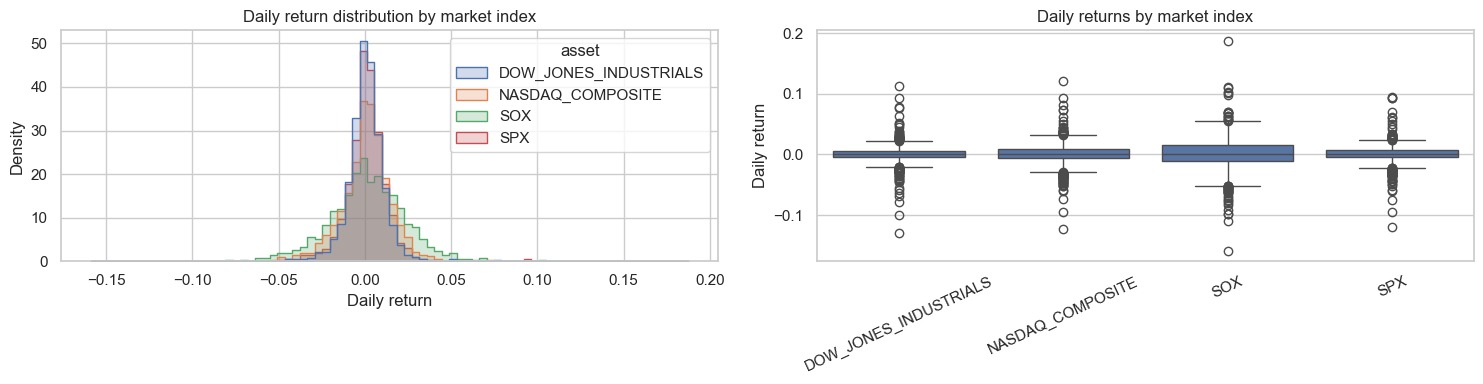

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

sns.histplot(
    data=market_daily_df,
    x="daily_return",
    hue="asset",
    bins=80,
    element="step",
    stat="density",
    common_norm=False,
    ax=axes[0],
)
axes[0].set_title("Daily return distribution by market index")
axes[0].set_xlabel("Daily return")

sns.boxplot(data=market_daily_df, x="asset", y="daily_return", ax=axes[1])
axes[1].set_title("Daily returns by market index")
axes[1].set_xlabel("")
axes[1].set_ylabel("Daily return")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


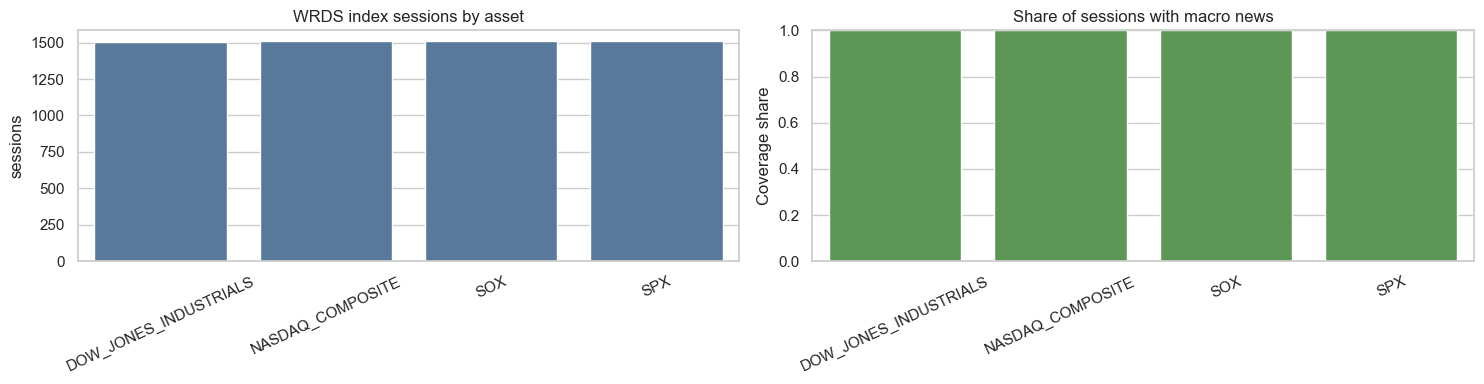

In [24]:
coverage_plot_df = coverage_summary.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.barplot(data=coverage_plot_df, x="asset", y="sessions", ax=axes[0], color="#4C78A8")
axes[0].set_title("WRDS index sessions by asset")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=25)

sns.barplot(data=coverage_plot_df, x="asset", y="macro_news_coverage_share", ax=axes[1], color="#54A24B")
axes[1].set_title("Share of sessions with macro news")
axes[1].set_xlabel("")
axes[1].set_ylabel("Coverage share")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


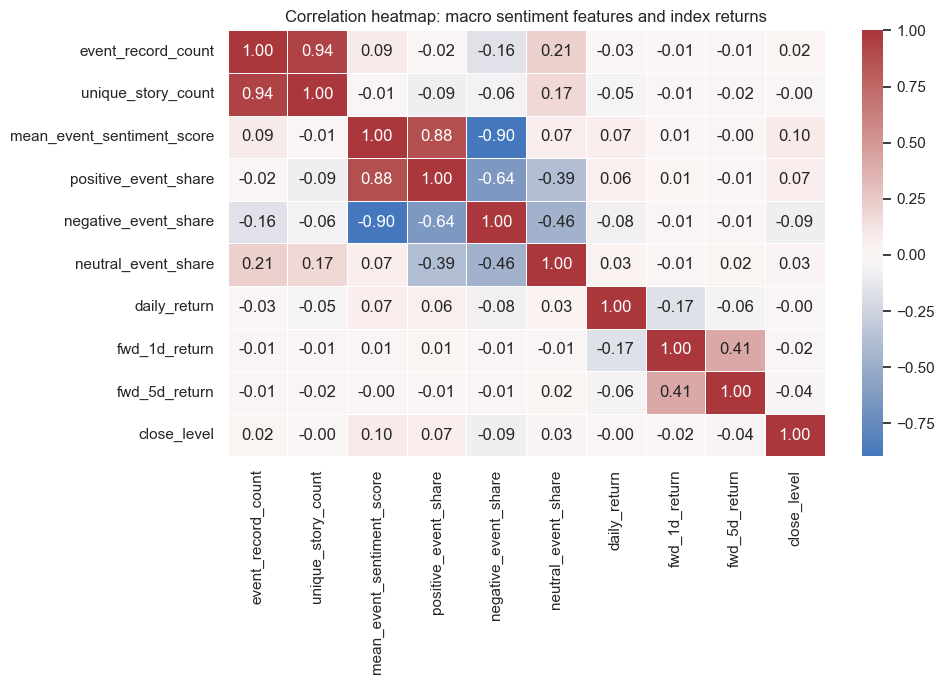

In [25]:
correlation_columns = [
    "event_record_count",
    "unique_story_count",
    "mean_event_sentiment_score",
    "positive_event_share",
    "negative_event_share",
    "neutral_event_share",
    "daily_return",
    "fwd_1d_return",
    "fwd_5d_return",
    "close_level",
]

corr_df = eda_panel_df[correlation_columns].replace([np.inf, -np.inf], np.nan).dropna(how="all")
correlation_matrix = corr_df.corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="vlag", center=0, linewidths=0.5)
plt.title("Correlation heatmap: macro sentiment features and index returns")
plt.tight_layout()
plt.show()


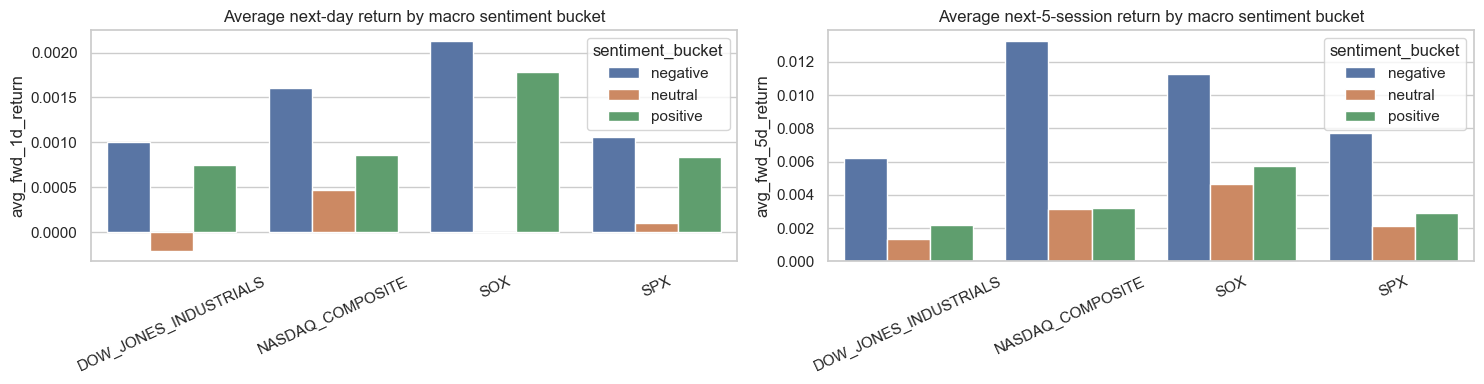

,asset,sentiment_bucket,observations,avg_fwd_1d_return,avg_fwd_5d_return,positive_1d_rate,positive_5d_rate
0,DOW_JONES_INDUSTRIALS,negative,77,0.001,0.006225,0.493506,0.597403
1,DOW_JONES_INDUSTRIALS,neutral,526,-0.000206,0.001366,0.511407,0.576046
2,DOW_JONES_INDUSTRIALS,positive,899,0.000753,0.00216,0.559511,0.578420
3,NASDAQ_COMPOSITE,negative,77,0.001611,0.013227,0.519481,0.649351
4,NASDAQ_COMPOSITE,neutral,526,0.000475,0.003131,0.553232,0.585551
5,NASDAQ_COMPOSITE,positive,900,0.000858,0.003197,0.566667,0.592222
6,SOX,negative,77,0.00213,0.01128,0.493506,0.623377
7,SOX,neutral,526,0.000007,0.004642,0.517110,0.557034
8,SOX,positive,900,0.001787,0.005717,0.537778,0.553333
9,SPX,negative,77,0.00106,0.007686,0.506494,0.610390


,asset,sentiment_bucket,observations,avg_fwd_1d_return,avg_fwd_5d_return,positive_1d_rate,positive_5d_rate
0,DOW_JONES_INDUSTRIALS,negative,77,0.001,0.006225,0.493506,0.597403
1,DOW_JONES_INDUSTRIALS,neutral,526,-0.000206,0.001366,0.511407,0.576046
2,DOW_JONES_INDUSTRIALS,positive,899,0.000753,0.00216,0.559511,0.578420
3,NASDAQ_COMPOSITE,negative,77,0.001611,0.013227,0.519481,0.649351
4,NASDAQ_COMPOSITE,neutral,526,0.000475,0.003131,0.553232,0.585551
5,NASDAQ_COMPOSITE,positive,900,0.000858,0.003197,0.566667,0.592222
6,SOX,negative,77,0.00213,0.01128,0.493506,0.623377
7,SOX,neutral,526,0.000007,0.004642,0.517110,0.557034
8,SOX,positive,900,0.001787,0.005717,0.537778,0.553333
9,SPX,negative,77,0.00106,0.007686,0.506494,0.610390


In [29]:
bucket_return_df = (
    eda_panel_df.dropna(subset=["sentiment_bucket", "fwd_1d_return", "fwd_5d_return"])
    .groupby(["asset", "sentiment_bucket"], as_index=False)
    .agg(
        observations=("session_date", "count"),
        avg_fwd_1d_return=("fwd_1d_return", "mean"),
        avg_fwd_5d_return=("fwd_5d_return", "mean"),
        positive_1d_rate=("fwd_1d_positive", "mean"),
        positive_5d_rate=("fwd_5d_positive", "mean"),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.barplot(data=bucket_return_df, x="asset", y="avg_fwd_1d_return", hue="sentiment_bucket", ax=axes[0])
axes[0].set_title("Average next-day return by macro sentiment bucket")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=25)

sns.barplot(data=bucket_return_df, x="asset", y="avg_fwd_5d_return", hue="sentiment_bucket", ax=axes[1])
axes[1].set_title("Average next-5-session return by macro sentiment bucket")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()
display(bucket_return_df.sort_values(["asset", "sentiment_bucket"]))
display(bucket_return_df)


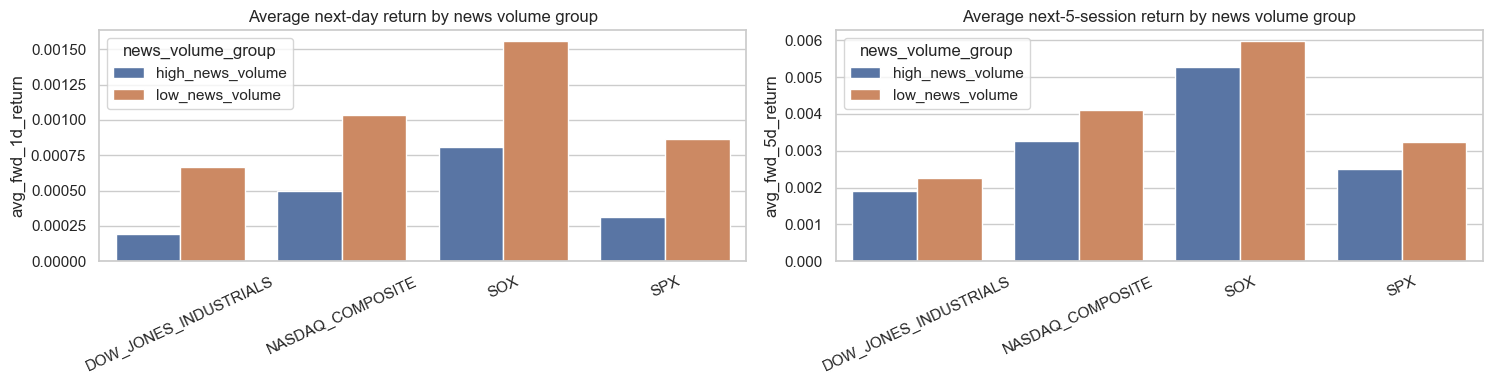

,asset,news_volume_group,observations,avg_fwd_1d_return,avg_fwd_5d_return,positive_1d_rate
0,DOW_JONES_INDUSTRIALS,high_news_volume,753,0.000192,0.001909,0.528552
1,DOW_JONES_INDUSTRIALS,low_news_volume,749,0.000669,0.002272,0.550067
2,NASDAQ_COMPOSITE,high_news_volume,754,0.000494,0.003269,0.554377
3,NASDAQ_COMPOSITE,low_news_volume,749,0.001033,0.00411,0.564753
4,SOX,high_news_volume,754,0.00081,0.005286,0.531830
5,SOX,low_news_volume,749,0.001555,0.005967,0.524700
6,SPX,high_news_volume,754,0.000315,0.002499,0.535809
7,SPX,low_news_volume,749,0.000867,0.003241,0.554072


In [27]:
volume_panel_df = eda_panel_df.copy()
volume_panel_df["news_volume_group"] = "no_news"
positive_volume = volume_panel_df["event_record_count"] > 0
volume_cutoff = volume_panel_df.loc[positive_volume, "event_record_count"].median()
volume_panel_df.loc[positive_volume & (volume_panel_df["event_record_count"] <= volume_cutoff), "news_volume_group"] = "low_news_volume"
volume_panel_df.loc[positive_volume & (volume_panel_df["event_record_count"] > volume_cutoff), "news_volume_group"] = "high_news_volume"

volume_return_df = (
    volume_panel_df.dropna(subset=["fwd_1d_return", "fwd_5d_return"])
    .groupby(["asset", "news_volume_group"], as_index=False)
    .agg(
        observations=("session_date", "count"),
        avg_fwd_1d_return=("fwd_1d_return", "mean"),
        avg_fwd_5d_return=("fwd_5d_return", "mean"),
        positive_1d_rate=("fwd_1d_positive", "mean"),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.barplot(data=volume_return_df, x="asset", y="avg_fwd_1d_return", hue="news_volume_group", ax=axes[0])
axes[0].set_title("Average next-day return by news volume group")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=25)

sns.barplot(data=volume_return_df, x="asset", y="avg_fwd_5d_return", hue="news_volume_group", ax=axes[1])
axes[1].set_title("Average next-5-session return by news volume group")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

display(volume_return_df)


In [31]:
quantile_df = eda_panel_df.dropna(subset=["mean_event_sentiment_score", "fwd_1d_return"]).copy()

quantile_df["sentiment_quantile"] = pd.qcut(
    quantile_df["mean_event_sentiment_score"],
    q=5,
    labels=["Lowest 20%", "Low", "Middle", "High", "Highest 20%"],
    duplicates="drop"
)

sentiment_quantile_returns = (
    quantile_df
    .groupby(["asset", "sentiment_quantile"], observed=True)
    .agg(
        observations=("session_date", "count"),
        avg_fwd_1d_return=("fwd_1d_return", "mean"),
        avg_fwd_5d_return=("fwd_5d_return", "mean"),
        positive_1d_rate=("fwd_1d_positive", "mean"),
    )
    .reset_index()
)

display(sentiment_quantile_returns)

,asset,sentiment_quantile,observations,avg_fwd_1d_return,avg_fwd_5d_return,positive_1d_rate
0,DOW_JONES_INDUSTRIALS,Lowest 20%,302,0.000215,0.001829,0.493377
1,DOW_JONES_INDUSTRIALS,Low,301,-0.000321,0.002145,0.524917
2,DOW_JONES_INDUSTRIALS,Middle,301,0.000003,0.000682,0.518272
3,DOW_JONES_INDUSTRIALS,High,301,0.001299,0.003369,0.584718
4,DOW_JONES_INDUSTRIALS,Highest 20%,301,0.000903,0.002426,0.568106
5,NASDAQ_COMPOSITE,Lowest 20%,302,0.001019,0.00607,0.566225
6,NASDAQ_COMPOSITE,Low,301,0.00022,0.002765,0.531561
7,NASDAQ_COMPOSITE,Middle,301,0.000212,0.001537,0.521595
8,NASDAQ_COMPOSITE,High,302,0.001064,0.003383,0.579470
9,NASDAQ_COMPOSITE,Highest 20%,301,0.001234,0.004661,0.591362


### SPX
- High sentiment: 0.111% next-day return
- Highest 20% sentiment: 0.109% next-day return
- Positive next-day rate rises to 58.5% in the highest sentiment group
### Nasdaq
- Highest 20% sentiment has the highest positive rate: 59.1%
- Highest 20% also has a higher 5-day return than the low/middle groups
### SOX
- High and Highest sentiment groups have strong next-day returns:
- High: 0.220%
- Highest 20%: 0.198%
- This makes sense because semiconductor stocks are more sensitive to macro risk appetite and growth sentiment.
### Dow
- High sentiment performs best:
- 0.130% next-day return
- 58.5% positive next-day rate

## Key Takeaways from This Basic EDA

1. WRDS connection and RavenPack table access were successful.
2. RavenPack macro-news data are available across the intended 2020–2025 sample period.
3. The dataset contains usable timestamp, source, relevance, topic, and sentiment fields.
4. News timestamps can be converted from UTC to Eastern Time and mapped to trading sessions.
5. WRDS market index data can be pulled and joined with daily RavenPack news aggregates.
6. This notebook validates the basic data pipeline, but it does not yet test the final firm-level S&P 500 prediction hypothesis.

## Next Step

The next notebook should move from macro index-level data to firm-level RavenPack news. A reasonable next step is to select a small sample of S&P 500 firms, pull their RavenPack company-level news, match news records to daily stock returns, and build a firm-date panel for future modeling.